# Morphology Profile Prediction

In order to evaluate our ability to predict morphology from functional data we attempt to fit every feature in the (control-normalized) CellProfiler profiles using shallow models.

Since we have per-well profiles, we will compare two approaches:

- Fitting and predicting per-gene profiles, that are obtained by averaging the well profiles for the gene knockouts
- Fitting per-well profiles and predicting average per-gene profiles. In this evaluation we will also look at feature predictability ranked against feature variance across wells.

## Load profiles

In [1]:
from pathlib import Path
import pandas as pd

data_folder = Path('../data/cpg0016/version_2024-04-15')

# Load profiles
normalized_profiles = pd.read_parquet(data_folder/'normalized_profiles').set_index(['Metadata_Plate', 'Metadata_Well'])

In [2]:
# Get the list of knockouts
knockouts = normalized_profiles[normalized_profiles['Metadata_Perturbation'] == 'CRISPR-trt']['Metadata_Symbol'].drop_duplicates()
knockouts

Metadata_Plate  Metadata_Well
CP-CC9-R1-01    A03              ARHGEF7
                A04                 ST13
                A05                 GPHN
                A06                 EXT2
                A07                SNUPN
                                  ...   
CP-CC9-R2-20    O16              SMARCA4
CP-CC9-R2-21    L08                TGIF1
CP-CC9-R2-26    N09               LRSAM1
CP-CC9-R6-02    C09               INPP5B
CP-CC9-R7-02    J10               SPTLC1
Name: Metadata_Symbol, Length: 7975, dtype: object

In [3]:
# Should we select only knockouts first?
profile_columns = normalized_profiles.columns[~normalized_profiles.columns.str.startswith('Metadata')]

# Compute average gene profiles
profiles_groupby = normalized_profiles.groupby('Metadata_Symbol')[profile_columns]
gene_profiles = profiles_groupby.mean()

# Compute gene profile variances
gene_profile_sd = profiles_groupby.std()

## Build feature vectors
Next we collect our functional features

In [4]:
# Gene abundances
cell_line_df = pd.read_table('../../../data/cellular-localization/gene_abundances_U2OS.tsv')
cell_line_df

,Enesembl ID,Gene,RNA line ab,RNA type ab,protein type ab
0,ENSG00000000003,TSPAN6,23.4,NaN,NaN
1,ENSG00000000005,TNMD,0.0,NaN,NaN
2,ENSG00000000419,DPM1,97.8,NaN,NaN
3,ENSG00000000457,SCYL3,3.6,NaN,NaN
4,ENSG00000000460,C1orf112,16.1,NaN,NaN
...,...,...,...,...,...
20077,ENSG00000288677,AC105206.4,1.7,NaN,NaN
20078,ENSG00000288678,AL136115.4,0.0,NaN,NaN
20079,ENSG00000288681,AC136475.9,0.0,NaN,NaN
20080,ENSG00000288684,AL353671.1,0.7,NaN,NaN


In [5]:
# Undetected genes
undetected_df = pd.read_table('../../../data/cellular-localization/undetected_genes_U2OS.tsv')
undetected_df

,Enesembl ID,Gene
0,ENSG00000159455,LCE2B
1,ENSG00000141255,SPATA22
2,ENSG00000259303,IGHV2OR16-5
3,ENSG00000186930,KRTAP6-2
4,ENSG00000211967,IGHV3-53
...,...,...
4041,ENSG00000142973,CYP4B1
4042,ENSG00000188120,DAZ1
4043,ENSG00000111783,RFX4
4044,ENSG00000188730,VWC2


We will use the `RNA line ab` column and encode protein absence with a binary variable (absent=0, present=1):

In [6]:
abundance_df = cell_line_df[['Gene', 'RNA line ab']]
abundance_df.loc[:, 'Protein present'] = 1
abundance_df.loc[abundance_df['Gene'].isin(undetected_df['Gene']), 'Protein present'] = 0
abundance_df = abundance_df.set_index('Gene')
abundance_df

/tmp/ipykernel_733617/2026915113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance_df.loc[:, 'Protein present'] = 1


,RNA line ab,Protein present
Gene,,
TSPAN6,23.4,1
TNMD,0.0,0
DPM1,97.8,1
SCYL3,3.6,1
C1orf112,16.1,1
...,...,...
AC105206.4,1.7,1
AL136115.4,0.0,0
AC136475.9,0.0,0


In [7]:
# Subcellular localization data
sc_df = (
    pd
    .read_table(
        '../../../data/subcellular-localization/uniprot_reactome_hpa_merged.tsv',
        usecols=['gene_id', 'hpa_location']
    )
    .drop_duplicates()
    .pivot_table(index='gene_id', columns='hpa_location', aggfunc=lambda _: 1, fill_value=0)
)
sc_df

hpa_location,actin filaments:cytoplasm,aggresome:cytosol:cytoplasm,cell junctions:plasma membrane:endomembrane system,centriolar satellite:centrosome:cytoplasm,centrosome:cytoplasm,cleavage furrow:actin filaments:cytoplasm,cytokinetic bridge:microtubules:cytoplasm,cytoplasm,cytoplasmic bodies:cytosol:cytoplasm,cytosol:cytoplasm,...,nucleoli rim:nucleoli:nucleus,nucleoli:nucleus,nucleoplasm:nucleus,nucleus,peroxisomes:vesicles:endomembrane system,plasma membrane:endomembrane system,rods & rings:cytosol:cytoplasm,secreted proteins:secretory,secretory,vesicles:endomembrane system
gene_id,,,,,,,,,,,,,,,,,,,,,
1C,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1a,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3a,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,1
3b,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vpr,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
vpu,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
wnt11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [8]:
# GO embeddings
go_embedding = pd.read_csv('../../../data/GO_Embeddings/go_embedding_64.csv', index_col=0)
go_embedding

,go_feature_0,go_feature_1,go_feature_2,go_feature_3,go_feature_4,go_feature_5,go_feature_6,go_feature_7,go_feature_8,go_feature_9,...,go_feature_54,go_feature_55,go_feature_56,go_feature_57,go_feature_58,go_feature_59,go_feature_60,go_feature_61,go_feature_62,go_feature_63
A1BG,-0.367388,-0.413445,-0.404171,-0.004415,0.247503,-0.102804,0.157222,0.135817,0.089900,0.074568,...,0.292506,0.002101,0.263603,0.169054,0.063430,-0.171397,0.077323,0.051098,-0.082001,-0.036673
ABG,-0.158945,-0.490194,-0.403563,-0.029135,0.218117,-0.182563,0.094209,0.367191,0.190919,0.060625,...,0.354492,0.080943,0.412824,0.237152,0.164620,-0.067162,0.131368,-0.198871,-0.009133,-0.123394
GAB,-0.180069,-0.461517,-0.384918,0.124994,0.370956,-0.238049,-0.142643,0.268287,0.099368,-0.046293,...,0.083225,0.151852,0.395230,0.325642,0.009123,0.005238,0.014833,-0.086011,-0.110260,-0.070421
HYST2477,-0.264915,-0.487703,-0.230273,-0.033565,0.199071,-0.205979,0.118402,0.201433,0.175869,0.112664,...,0.110051,0.018307,0.547518,0.345197,0.265257,-0.011448,-0.016393,-0.227499,-0.241314,-0.233270
AGP-B,-0.503596,-0.640465,-0.509292,0.149607,0.393729,-0.390091,0.261283,0.243027,0.251378,-0.035333,...,0.491511,0.201053,0.626971,0.418596,0.004392,0.176189,0.066519,-0.039353,0.027906,-0.251306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BECN2,0.244011,-0.263258,-0.058161,0.086946,-0.049276,0.201113,-0.158159,-0.080029,0.105038,-0.029396,...,0.111178,0.110147,0.376339,0.228923,-0.087186,0.278534,-0.173626,-0.059988,0.162028,-0.135971
BECN1L1,0.232987,-0.238887,0.152314,0.086158,0.211937,0.196062,-0.173626,0.207144,0.054919,-0.048840,...,0.261120,-0.020350,0.431131,0.151029,0.037241,0.242878,-0.135145,-0.076569,0.097100,-0.015145
BECN1P1,0.203444,-0.165649,-0.144183,0.142063,0.079616,0.128623,-0.151379,-0.144399,0.001635,0.177796,...,0.199253,-0.054431,0.236613,-0.019560,-0.047433,0.272289,-0.071594,0.187233,-0.104395,0.001068
SULT1C3,0.061440,0.042919,-0.101767,0.142327,0.153482,0.057794,-0.162811,0.157489,0.196053,-0.061985,...,0.026004,-0.056475,0.208966,-0.208943,-0.094607,-0.046538,-0.100566,0.038614,-0.121547,0.020993


### Assembling the feature vectors for genes

In [9]:
normalized_profiles

Metadata_Source Metadata_JCP2022  \
Metadata_Plate Metadata_Well                                    
CP-CC9-R1-01   A02                 source_13   JCP2022_800002   
               A03                 source_13   JCP2022_800573   
               A04                 source_13   JCP2022_806794   
               A05                 source_13   JCP2022_802800   
               A06                 source_13   JCP2022_802216   
...                                      ...              ...   
CP-CC9-R8-02   P20                 source_13   JCP2022_801694   
               P21                 source_13   JCP2022_804281   
               P22                 source_13   JCP2022_800983   
               P23                 source_13   JCP2022_800001   
               P24                 source_13   JCP2022_046054   

                                          Metadata_Symbol  \
Metadata_Plate Metadata_Well                                
CP-CC9-R1-01   A02                          non-targeting   
               A03                                ARHGEF7   
               A04                                   ST13   
               A05                                   GPHN   
               A06                                   EXT2   
...                                                   ...   
CP-CC9-R8-02   P20                                DCLRE1A   
               P21                                  MS4A8   
               P22                                    CA7   
               P23                               no-guide   
               P24            KPBNHDGDUADAGP-UHFFFAOYSA-N   

                             Metadata_NCBI_Gene_ID Metadata_Perturbation  \
Metadata_Plate Metadata_Well                                               
CP-CC9-R1-01   A02                            None  CRISPR-non-targeting   
               A03                            8874            CRISPR-trt   
               A04                            6767            CRISPR-trt   
               A05                           10243            CRISPR-trt   
               A06                            2132            CRISPR-trt   
...                                            ...                   ...   
CP-CC9-R8-02   P20                            9937            CRISPR-trt   
               P21                           83661            CRISPR-trt   
               P22                             766            CRISPR-trt   
               P23                            None       CRISPR-no-guide   
               P24                            None          Compound-trt   

                              Cells_AreaShape_Area  \
Metadata_Plate Metadata_Well                         
CP-CC9-R1-01   A02                        2.300298   
               A03                        1.428099   
               A04                        5.046471   
               A05                        4.724336   
               A06                        5.282117   
...                                            ...   
CP-CC9-R8-02   P20                        4.961450   
               P21                        6.771890   
               P22                        5.684483   
               P23                        0.862481   
               P24                        8.697691   

                              Cells_AreaShape_BoundingBoxArea  \
Metadata_Plate Metadata_Well                                    
CP-CC9-R1-01   A02                                   2.341745   
               A03                                   1.455535   
               A04                                   5.163721   
               A05                                   4.665389   
               A06                                   5.154575   
...                                                       ...   
CP-CC9-R8-02   P20                                   5.206949   
               P21                                   7.169979   
               P22                             

In [10]:
gene_features = (
    go_embedding
    .merge(
        abundance_df,
        how='inner',
        left_index=True,
        right_index=True            
    )
    .merge(
        sc_df,
        how='inner',
        left_index=True,
        right_index=True
    )
    .filter(knockouts.values, axis='index')
)
gene_features

,go_feature_0,go_feature_1,go_feature_2,go_feature_3,go_feature_4,go_feature_5,go_feature_6,go_feature_7,go_feature_8,go_feature_9,...,nucleoli rim:nucleoli:nucleus,nucleoli:nucleus,nucleoplasm:nucleus,nucleus,peroxisomes:vesicles:endomembrane system,plasma membrane:endomembrane system,rods & rings:cytosol:cytoplasm,secreted proteins:secretory,secretory,vesicles:endomembrane system
ARHGEF7,-0.026157,0.270363,-0.012067,-0.048316,-0.279409,0.421900,-0.021248,-0.049943,-0.372550,-0.305117,...,0,0,0,0,0,1,0,0,0,0
ST13,0.048808,0.410969,-0.175275,-0.239045,-0.211543,-0.011568,0.038356,-0.111826,-0.081557,-0.292597,...,0,0,0,0,0,0,0,0,0,0
GPHN,-0.194735,0.018474,-0.404345,-0.730726,0.118699,0.328228,0.230007,0.089204,0.200459,0.176632,...,0,0,0,0,0,1,0,0,0,1
EXT2,-0.299398,-0.124381,0.230368,0.313690,-0.398232,0.218384,-0.242816,-0.126449,0.032062,0.281211,...,0,0,0,0,0,1,0,0,0,0
SNUPN,-0.198927,-0.017670,0.238348,-0.662525,0.175092,-0.073135,0.064495,-0.274922,0.192004,-0.109734,...,0,0,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMARCA4,-0.116380,-0.031098,0.224653,-0.004805,0.037361,0.057209,-0.426389,-0.079058,-0.190997,0.174423,...,1,0,1,1,0,0,0,0,0,0
TGIF1,-0.060096,0.200586,0.044254,0.219260,0.617277,-0.712560,0.364348,-0.106019,0.988198,-0.077785,...,0,0,1,1,0,0,0,0,0,0
LRSAM1,0.215996,-0.031141,-0.161843,0.064541,-0.080942,-0.096385,0.155341,0.166363,0.242895,-0.078426,...,0,0,0,0,0,0,0,0,0,0
INPP5B,-0.481273,-0.089913,-0.269092,-0.197013,0.018411,-0.661802,0.060325,0.021351,-0.222220,0.192664,...,0,0,0,0,0,1,0,0,0,1


## Running predictions

We set up 10 cross-validation folds (by gene)

In [11]:
feature_columns = gene_features.columns
profile_columns = normalized_profiles.columns
profile_columns = profile_columns[~profile_columns.str.startswith('Metadata_')]

well_features_and_profiles = gene_features.merge(
    normalized_profiles,
    left_index=True,
    right_on='Metadata_Symbol'
)
well_features_and_profiles

go_feature_0  go_feature_1  go_feature_2  \
Metadata_Plate Metadata_Well                                             
CP-CC9-R1-01   A03               -0.026157      0.270363     -0.012067   
CP-CC9-R2-01   A03               -0.026157      0.270363     -0.012067   
CP-CC9-R3-01   A03               -0.026157      0.270363     -0.012067   
CP-CC9-R5-01   A03               -0.026157      0.270363     -0.012067   
CP-CC9-R6-01   A03               -0.026157      0.270363     -0.012067   
...                                    ...           ...           ...   
CP-CC9-R5-26   N09                0.215996     -0.031141     -0.161843   
CP-CC9-R6-02   D20                0.215996     -0.031141     -0.161843   
               C09               -0.481273     -0.089913     -0.269092   
CP-CC9-R7-02   J10                1.116004      0.357126      0.019172   
CP-CC9-R8-02   J10                1.116004      0.357126      0.019172   

                              go_feature_3  go_feature_4  go_feature_5  \
Metadata_Plate Metadata_Well                                             
CP-CC9-R1-01   A03               -0.048316     -0.279409      0.421900   
CP-CC9-R2-01   A03               -0.048316     -0.279409      0.421900   
CP-CC9-R3-01   A03               -0.048316     -0.279409      0.421900   
CP-CC9-R5-01   A03               -0.048316     -0.279409      0.421900   
CP-CC9-R6-01   A03               -0.048316     -0.279409      0.421900   
...                                    ...           ...           ...   
CP-CC9-R5-26   N09                0.064541     -0.080942     -0.096385   
CP-CC9-R6-02   D20                0.064541     -0.080942     -0.096385   
               C09               -0.197013      0.018411     -0.661802   
CP-CC9-R7-02   J10               -0.402762      0.103972      0.251096   
CP-CC9-R8-02   J10               -0.402762      0.103972      0.251096   

                              go_feature_6  go_feature_7  go_feature_8  \
Metadata_Plate Metadata_Well                                             
CP-CC9-R1-01   A03               -0.021248     -0.049943     -0.372550   
CP-CC9-R2-01   A03               -0.021248     -0.049943     -0.372550   
CP-CC9-R3-01   A03               -0.021248     -0.049943     -0.372550   
CP-CC9-R5-01   A03               -0.021248     -0.049943     -0.372550   
CP-CC9-R6-01   A03               -0.021248     -0.049943     -0.372550   
...                                    ...           ...           ...   
CP-CC9-R5-26   N09                0.155341      0.166363      0.242895   
CP-CC9-R6-02   D20                0.155341      0.166363      0.242895   
               C09                0.060325      0.021351     -0.222220   
CP-CC9-R7-02   J10                0.166950      0.105205      0.255904   
CP-CC9-R8-02   J10                0.166950      0.105205      0.255904   

                              go_feature_9  ...  \
Metadata_Plate Metadata_Well                ...   
CP-CC9-R1-01   A03               -0.305117  ...   
CP-CC9-R2-01   A03               -0.305117  ...   
CP-CC9-R3-01   A03               -0.305117  ...   
CP-CC9-R5-01   A03               -0.305117  ...   
CP-CC9-R6-01   A03               -0.305117  ...   
...                                    ...  ...   
CP-CC9-R5-26   N09               -0.078426  ...   
CP-CC9-R6-02   D20               -0.078426  ...   
               C09                0.192664  ...   
CP-CC9-R7-02   J10                0.024051  ...   
CP-CC9-R8-02   J10                0.024051  ...   

                              Nuclei_Texture_Variance_RNA_10_02_256  \
Metadata_Plate Metadata_Well                                          
CP-CC9-R1-01   A03                                         1.993060   
CP-CC9-R2-01   A03                                         3.843377   
CP-CC9-R3-01   A03                                         1.867596   
CP-CC9-R5-01   A03                                         3.107189   
CP-CC9-R6-01   A03                                 

Only recompute results if needed. We use dates for versioning.

In [12]:
# Which version of the results to try to load
load_version = '2024-04-26'

from sklearn.linear_model import LinearRegression, Lasso

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso()
}

In [ ]:
model_paths = {
    name: Path(f'results/{name} {load_version}.csv')
    for name in models.keys()
}

models_to_train = [
    (name, model_paths[name], model)
    for name, model in models.items()
    if not model_paths[name].exists()
]

In [ ]:
import numpy as np
from datetime import date
from sklearn.model_selection import KFold, cross_val_predict


splits = KFold(n_splits=10, shuffle=True, random_state=20240425).split(gene_features)

gene_list = gene_features.index

well_splits = [
    (
        np.flatnonzero(well_features_and_profiles['Metadata_Symbol'].isin(gene_list[train])),
        np.flatnonzero(well_features_and_profiles['Metadata_Symbol'].isin(gene_list[test]))
    )
    for train, test in splits
]

cv_predictions = (
    (
        name,
        path,
        well_features_and_profiles[profile_columns].apply(
            lambda profile_component:
                cross_val_predict(
                    model,
                    well_features_and_profiles[feature_columns],
                    profile_component,
                    cv=well_splits,
                    n_jobs=-1
                )
        )
    )
    for name, path, model in models_to_train
)

# Save
for _, path, df in cv_predictions:
    df.to_csv(path)

In [ ]:
# Load predictions
cv_predictions = {
    name: pd.read_csv(path, index_col=[0,1])
    for name, path in model_paths.items()
}

In [ ]:
cv_mse = pd.concat(
    {
        name:
            ((df - well_features_and_profiles[profile_columns])**2).mean(axis='index')
        for name, df in cv_predictions.items()
    },
    names=['Model']
)

cv_mse

Model                                                  
Linear Regression  Cells_AreaShape_Area                     97.623354
                   Cells_AreaShape_BoundingBoxArea         102.801505
                   Cells_AreaShape_BoundingBoxMaximum_X      9.060798
                   Cells_AreaShape_BoundingBoxMaximum_Y     33.208043
                   Cells_AreaShape_BoundingBoxMinimum_X     16.200478
                                                              ...    
Lasso              Nuclei_Texture_Variance_RNA_3_03_256     27.473147
                   Nuclei_Texture_Variance_RNA_5_00_256     27.477348
                   Nuclei_Texture_Variance_RNA_5_01_256     27.555248
                   Nuclei_Texture_Variance_RNA_5_02_256     27.424177
                   Nuclei_Texture_Variance_RNA_5_03_256     27.582919
Length: 9520, dtype: float64

In [13]:
# Total sum of squares in profiles
profile_tss = (
    (
        well_features_and_profiles[profile_columns]
        - well_features_and_profiles[profile_columns].mean(axis='index')
    ) ** 2
).sum(axis='index')

# Compute R squared
cv_rsquared = pd.concat(
    {
        name:
            1 - ((df - well_features_and_profiles[profile_columns])**2).sum(axis='index') / profile_tss
        for name, df in cv_predictions.items()
    }
)

cv_rsquared

NameError: name 'cv_predictions' is not defined

In [ ]:
cv_rsquared_df = cv_rsquared.sort_values(ascending=False).to_frame(name='R Squared')
cv_rsquared_df.index.set_names(['Model', 'Feature'], inplace=True)
cv_rsquared_df.reset_index(inplace=True)
cv_rsquared_df

,Model,Feature,R Squared
0,Linear Regression,Nuclei_RadialDistribution_RadialCV_Mito_1of4,0.115329
1,Linear Regression,Cells_Neighbors_AngleBetweenNeighbors_Adjacent,0.106563
2,Linear Regression,Cells_Neighbors_AngleBetweenNeighbors_5,0.106563
3,Linear Regression,Image_Granularity_8_DNA,0.100560
4,Linear Regression,Cells_RadialDistribution_MeanFrac_mito_tubenes...,0.097821
...,...,...,...
9515,Lasso,Nuclei_Location_MaxIntensity_Z_AGP,NaN
9516,Lasso,Nuclei_Location_MaxIntensity_Z_DNA,NaN
9517,Lasso,Nuclei_Location_MaxIntensity_Z_ER,NaN
9518,Lasso,Nuclei_Location_MaxIntensity_Z_Mito,NaN


[[Text(0, 0, ''),
  Text(1, 0, ''),
  Text(2, 0, ''),
  Text(3, 0, ''),
  Text(4, 0, ''),
  Text(5, 0, ''),
  Text(6, 0, ''),
  Text(7, 0, ''),
  Text(8, 0, ''),
  Text(9, 0, ''),
  Text(10, 0, ''),
  Text(11, 0, ''),
  Text(12, 0, ''),
  Text(13, 0, ''),
  Text(14, 0, ''),
  Text(15, 0, ''),
  Text(16, 0, ''),
  Text(17, 0, ''),
  Text(18, 0, ''),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, ''),
  Text(24, 0, ''),
  Text(25, 0, ''),
  Text(26, 0, ''),
  Text(27, 0, ''),
  Text(28, 0, ''),
  Text(29, 0, ''),
  Text(30, 0, ''),
  Text(31, 0, ''),
  Text(32, 0, ''),
  Text(33, 0, ''),
  Text(34, 0, ''),
  Text(35, 0, ''),
  Text(36, 0, ''),
  Text(37, 0, ''),
  Text(38, 0, ''),
  Text(39, 0, ''),
  Text(40, 0, ''),
  Text(41, 0, ''),
  Text(42, 0, ''),
  Text(43, 0, ''),
  Text(44, 0, ''),
  Text(45, 0, ''),
  Text(46, 0, ''),
  Text(47, 0, ''),
  Text(48, 0, ''),
  Text(49, 0, ''),
  Text(50, 0, ''),
  Text(51, 0, ''),
  Text(52, 0, ''),
  T

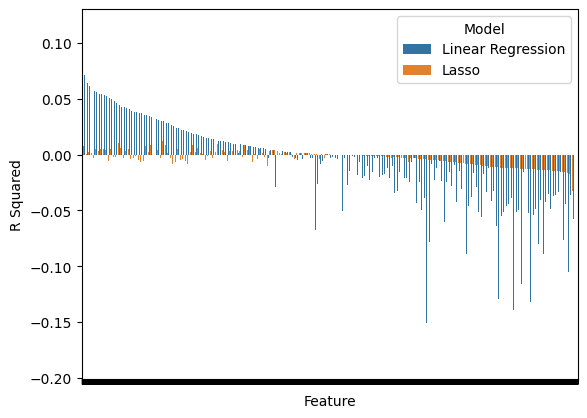

In [ ]:
import seaborn as sns

g = sns.barplot(
    data=cv_rsquared_df,
    x='Feature',
    y='R Squared',
    hue='Model'
)
g.set(xticklabels=[])

# Learnability

Cross-validation suggests that we cannot learn linear predictiors for profiles that generalize well.

Next we will study how well linear and non-linear predictors can fit the profiles in general.
We will fit and measure $R^2$ on the full data without spitting into test and train.

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

learnability_model_version = '2024-05-13'

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(max_iter=10000),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=1000)
}

lab_model_paths = {name: Path(f'results/Learnable {name} {learnability_model_version}.parquet') for name in models.keys()}

lab_models_to_fit = [] if True else [
    (name, lab_model_paths[name], model)
    for name, model in models.items()
    if not lab_model_paths[name].exists()
]

In [15]:
for name, path, model in lab_models_to_fit:
    print(f'Fitting {name}...')
    df = well_features_and_profiles[profile_columns].apply(
        lambda profile_component: (
            model
            .fit(well_features_and_profiles[feature_columns], profile_component)
            .predict(well_features_and_profiles[feature_columns])
        )
    )
    print(f'Saving to {path}')
    df.to_parquet(path)

Learnability evaluation results:

In [16]:
# Compute R^2 and plot learnability of features

lab_predictions = {
    name: pd.read_parquet(path)
    for name, path in lab_model_paths.items()
    if path.exists()
}

# Compute R squared
lab_rsquared = pd.concat(
    {
        name:
            1 - ((df - well_features_and_profiles[profile_columns])**2).sum(axis='index') / profile_tss
        for name, df in lab_predictions.items()
    }
)

lab_rsquared_df = lab_rsquared.sort_values(ascending=False).to_frame(name='R Squared')
lab_rsquared_df.index.set_names(['Model', 'Feature'], inplace=True)
lab_rsquared_df.reset_index(inplace=True)
lab_rsquared_df

NameError: name 'sns' is not defined

[[Text(0, 0, ''),
  Text(1, 0, ''),
  Text(2, 0, ''),
  Text(3, 0, ''),
  Text(4, 0, ''),
  Text(5, 0, ''),
  Text(6, 0, ''),
  Text(7, 0, ''),
  Text(8, 0, ''),
  Text(9, 0, ''),
  Text(10, 0, ''),
  Text(11, 0, ''),
  Text(12, 0, ''),
  Text(13, 0, ''),
  Text(14, 0, ''),
  Text(15, 0, ''),
  Text(16, 0, ''),
  Text(17, 0, ''),
  Text(18, 0, ''),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, ''),
  Text(24, 0, ''),
  Text(25, 0, ''),
  Text(26, 0, ''),
  Text(27, 0, ''),
  Text(28, 0, ''),
  Text(29, 0, ''),
  Text(30, 0, ''),
  Text(31, 0, ''),
  Text(32, 0, ''),
  Text(33, 0, ''),
  Text(34, 0, ''),
  Text(35, 0, ''),
  Text(36, 0, ''),
  Text(37, 0, ''),
  Text(38, 0, ''),
  Text(39, 0, ''),
  Text(40, 0, ''),
  Text(41, 0, ''),
  Text(42, 0, ''),
  Text(43, 0, ''),
  Text(44, 0, ''),
  Text(45, 0, ''),
  Text(46, 0, ''),
  Text(47, 0, ''),
  Text(48, 0, ''),
  Text(49, 0, ''),
  Text(50, 0, ''),
  Text(51, 0, ''),
  Text(52, 0, ''),
  T

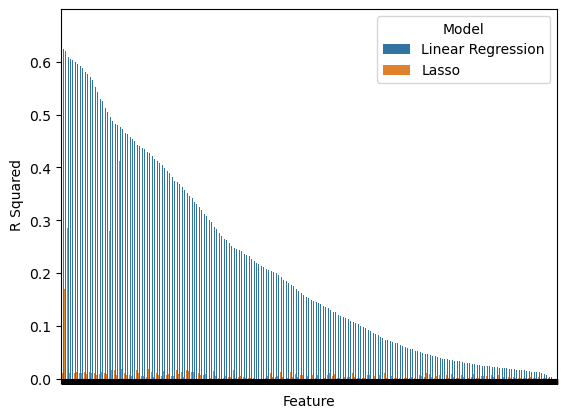

In [17]:
import seaborn as sns

g = sns.barplot(
    data=lab_rsquared_df,
    x='Feature',
    y='R Squared',
    hue='Model'
)
g.set(xticklabels=[])